In [1]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt

print("CrickOpt environment is working!")
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Scikit-learn:", sklearn.__version__)

CrickOpt environment is working!
Pandas: 3.0.5
NumPy: 2.5.3
Scikit-learn: 1.9.1


In [2]:
import pandas as pd
from pathlib import Path

# CrickOpt data folder
data_path = Path("../data/odis_csv2")

# Find all match CSV files (ignore *_info.csv files)
match_files = [
    f for f in data_path.glob("*.csv")
    if not f.name.endswith("_info.csv")
]

print("Number of match files:", len(match_files))
print("First 5 files:")
for f in match_files[:5]:
    print(f.name)

Number of match files: 3182
First 5 files:
1000887.csv
1000889.csv
1000891.csv
1000893.csv
1000895.csv


In [3]:
# Load the first match
sample_match = pd.read_csv(match_files[0])

print("Shape:", sample_match.shape)
print("\nColumns:")
print(sample_match.columns.tolist())

print("\nFirst 5 rows:")
display(sample_match.head())

Shape: (571, 27)

Columns:
['match_id', 'season', 'start_date', 'venue', 'innings', 'ball', 'actual_delivery', 'batting_team', 'bowling_team', 'striker', 'non_striker', 'bowler', 'runs_off_bat', 'extras', 'wides', 'noballs', 'byes', 'legbyes', 'penalty', 'non_boundary', 'wicket_type', 'player_dismissed', 'other_wicket_type', 'other_player_dismissed', 'fielder_1', 'fielder_2', 'fielder_3']

First 5 rows:


,match_id,season,start_date,venue,innings,ball,actual_delivery,batting_team,bowling_team,striker,...,legbyes,penalty,non_boundary,wicket_type,player_dismissed,other_wicket_type,other_player_dismissed,fielder_1,fielder_2,fielder_3
0,1000887,2016/17,2017-01-13,"Brisbane Cricket Ground, Woolloongabba",1,0.1,0.1,Australia,Pakistan,DA Warner,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1000887,2016/17,2017-01-13,"Brisbane Cricket Ground, Woolloongabba",1,0.2,0.2,Australia,Pakistan,DA Warner,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1000887,2016/17,2017-01-13,"Brisbane Cricket Ground, Woolloongabba",1,0.3,0.3,Australia,Pakistan,DA Warner,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1000887,2016/17,2017-01-13,"Brisbane Cricket Ground, Woolloongabba",1,0.4,0.4,Australia,Pakistan,DA Warner,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1000887,2016/17,2017-01-13,"Brisbane Cricket Ground, Woolloongabba",1,0.5,0.5,Australia,Pakistan,DA Warner,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Combine all ODI match files into one dataset

all_matches = []

for file in match_files:
    df = pd.read_csv(file)
    all_matches.append(df)

odi_data = pd.concat(all_matches, ignore_index=True)

print("Total rows:", len(odi_data))
print("Total columns:", len(odi_data.columns))

print("\nDataset shape:", odi_data.shape)

Total rows: 1683966
Total columns: 27

Dataset shape: (1683966, 27)


In [5]:
# Check all columns and their data types

print("COLUMN INFORMATION")
print("=" * 50)

for i, col in enumerate(odi_data.columns, 1):
    print(f"{i}. {col}  -->  {odi_data[col].dtype}")

COLUMN INFORMATION
1. match_id  -->  int64
2. season  -->  object
3. start_date  -->  str
4. venue  -->  str
5. innings  -->  int64
6. ball  -->  float64
7. actual_delivery  -->  float64
8. batting_team  -->  str
9. bowling_team  -->  str
10. striker  -->  str
11. non_striker  -->  str
12. bowler  -->  str
13. runs_off_bat  -->  int64
14. extras  -->  int64
15. wides  -->  float64
16. noballs  -->  float64
17. byes  -->  float64
18. legbyes  -->  float64
19. penalty  -->  float64
20. non_boundary  -->  object
21. wicket_type  -->  object
22. player_dismissed  -->  object
23. other_wicket_type  -->  object
24. other_player_dismissed  -->  object
25. fielder_1  -->  object
26. fielder_2  -->  object
27. fielder_3  -->  object


In [6]:
# Check missing values in each column

missing_values = odi_data.isnull().sum()

print("MISSING VALUES")
print("=" * 50)

print(missing_values)

MISSING VALUES
match_id                        0
season                          0
start_date                      0
venue                           0
innings                         0
ball                            0
actual_delivery                 0
batting_team                    0
bowling_team                    0
striker                         0
non_striker                     0
bowler                          0
runs_off_bat                    0
extras                          0
wides                     1643323
noballs                   1677970
byes                      1681247
legbyes                   1668043
penalty                   1683943
non_boundary              1683756
wicket_type               1637826
player_dismissed          1637826
other_wicket_type         1683964
other_player_dismissed    1683964
fielder_1                 1654222
fielder_2                 1682527
fielder_3                 1683911
dtype: int64


In [7]:
# Check for duplicate rows

duplicates = odi_data.duplicated().sum()

print("Duplicate rows:", duplicates)

Duplicate rows: 0


In [8]:
# Keep the important columns for CrickOpt

useful_columns = [
    "match_id",
    "season",
    "start_date",
    "venue",
    "innings",
    "ball",
    "actual_delivery",
    "batting_team",
    "bowling_team",
    "striker",
    "non_striker",
    "bowler",
    "runs_off_bat",
    "extras",
    "wides",
    "noballs",
    "byes",
    "legbyes",
    "wicket_type",
    "player_dismissed"
]

crickopt_data = odi_data[useful_columns].copy()

# Create total runs from runs off bat + extras
crickopt_data["total_runs"] = (
    crickopt_data["runs_off_bat"].fillna(0) +
    crickopt_data["extras"].fillna(0)
)

print("Original shape:", odi_data.shape)
print("CrickOpt dataset shape:", crickopt_data.shape)

display(crickopt_data.head())

Original shape: (1683966, 27)
CrickOpt dataset shape: (1683966, 21)


,match_id,season,start_date,venue,innings,ball,actual_delivery,batting_team,bowling_team,striker,...,bowler,runs_off_bat,extras,wides,noballs,byes,legbyes,wicket_type,player_dismissed,total_runs
0,1000887,2016/17,2017-01-13,"Brisbane Cricket Ground, Woolloongabba",1,0.1,0.1,Australia,Pakistan,DA Warner,...,Mohammad Amir,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0
1,1000887,2016/17,2017-01-13,"Brisbane Cricket Ground, Woolloongabba",1,0.2,0.2,Australia,Pakistan,DA Warner,...,Mohammad Amir,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0
2,1000887,2016/17,2017-01-13,"Brisbane Cricket Ground, Woolloongabba",1,0.3,0.3,Australia,Pakistan,DA Warner,...,Mohammad Amir,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0
3,1000887,2016/17,2017-01-13,"Brisbane Cricket Ground, Woolloongabba",1,0.4,0.4,Australia,Pakistan,DA Warner,...,Mohammad Amir,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0
4,1000887,2016/17,2017-01-13,"Brisbane Cricket Ground, Woolloongabba",1,0.5,0.5,Australia,Pakistan,DA Warner,...,Mohammad Amir,0,1,1.0,NaN,NaN,NaN,NaN,NaN,1


In [9]:
# Check missing values in our cleaned dataset

print("Missing values:")
print(crickopt_data.isnull().sum())

print("\nTotal duplicate rows:")
print(crickopt_data.duplicated().sum())

Missing values:
match_id                  0
season                    0
start_date                0
venue                     0
innings                   0
ball                      0
actual_delivery           0
batting_team              0
bowling_team              0
striker                   0
non_striker               0
bowler                    0
runs_off_bat              0
extras                    0
wides               1643323
noballs             1677970
byes                1681247
legbyes             1668043
wicket_type         1637826
player_dismissed    1637826
total_runs                0
dtype: int64

Total duplicate rows:
0


In [10]:
# Handle missing values

# Numerical columns: no runs/extras means 0
numeric_columns = [
    "runs_off_bat",
    "extras",
    "wides",
    "noballs",
    "byes",
    "legbyes",
    "total_runs"
]

for col in numeric_columns:
    crickopt_data[col] = crickopt_data[col].fillna(0)

# Wicket information: NaN means no wicket
crickopt_data["wicket_type"] = crickopt_data["wicket_type"].fillna("No wicket")
crickopt_data["player_dismissed"] = crickopt_data["player_dismissed"].fillna("None")

print("Missing values after cleaning:")
print(crickopt_data.isnull().sum().sum())

Missing values after cleaning:
0


In [11]:
# Create tactical features for CrickOpt

# Sort data correctly
crickopt_data = crickopt_data.sort_values(
    ["match_id", "innings", "actual_delivery"]
).reset_index(drop=True)

# Current score
crickopt_data["current_score"] = (
    crickopt_data.groupby(["match_id", "innings"])["total_runs"]
    .cumsum()
)

# Wicket indicator
crickopt_data["wicket"] = (
    crickopt_data["wicket_type"] != "No wicket"
).astype(int)

# Wickets lost so far
crickopt_data["wickets_lost"] = (
    crickopt_data.groupby(["match_id", "innings"])["wicket"]
    .cumsum()
)

# Over number
crickopt_data["over_number"] = (
    crickopt_data["actual_delivery"].astype(str)
    .str.split(".")
    .str[0]
    .astype(int)
)

# Match phase
def get_phase(over):
    if over < 10:
        return "Powerplay"
    elif over < 40:
        return "Middle"
    else:
        return "Death"

crickopt_data["phase"] = crickopt_data["over_number"].apply(get_phase)

print("Tactical features created successfully!")

display(
    crickopt_data[
        [
            "match_id",
            "innings",
            "over_number",
            "striker",
            "bowler",
            "runs_off_bat",
            "total_runs",
            "current_score",
            "wickets_lost",
            "phase"
        ]
    ].head(10)
)

Tactical features created successfully!


,match_id,innings,over_number,striker,bowler,runs_off_bat,total_runs,current_score,wickets_lost,phase
0,64814,1,0,SP Fleming,J Srinath,0,1,1,0,Powerplay
1,64814,1,0,NJ Astle,J Srinath,0,0,1,0,Powerplay
2,64814,1,0,NJ Astle,J Srinath,0,0,1,0,Powerplay
3,64814,1,0,NJ Astle,J Srinath,1,1,2,0,Powerplay
4,64814,1,0,SP Fleming,J Srinath,0,0,2,0,Powerplay
5,64814,1,0,SP Fleming,J Srinath,0,0,2,0,Powerplay
6,64814,1,1,NJ Astle,Z Khan,0,1,3,0,Powerplay
7,64814,1,1,NJ Astle,Z Khan,0,0,3,0,Powerplay
8,64814,1,1,NJ Astle,Z Khan,0,0,3,0,Powerplay
9,64814,1,1,NJ Astle,Z Khan,0,0,3,0,Powerplay


In [12]:
# Create target variables for the AI model

# What happens on the NEXT ball?
crickopt_data["next_ball_runs"] = (
    crickopt_data
    .groupby(["match_id", "innings"])["total_runs"]
    .shift(-1)
)

crickopt_data["next_ball_wicket"] = (
    crickopt_data
    .groupby(["match_id", "innings"])["wicket"]
    .shift(-1)
)

# Remove the final ball of each innings
# because there is no next ball to predict
crickopt_data = crickopt_data.dropna(
    subset=["next_ball_runs", "next_ball_wicket"]
).reset_index(drop=True)

print("Target variables created!")

print("\nNext-ball runs distribution:")
print(crickopt_data["next_ball_runs"].value_counts().sort_index())

print("\nNext-ball wicket distribution:")
print(crickopt_data["next_ball_wicket"].value_counts())

print("\nFinal dataset shape:", crickopt_data.shape)

Target variables created!

Next-ball runs distribution:
next_ball_runs
0.0    883037
1.0    549297
2.0     87132
3.0     10518
4.0    124597
5.0      2298
6.0     20650
7.0       134
Name: count, dtype: int64

Next-ball wicket distribution:
next_ball_wicket
0.0    1631639
1.0      46024
Name: count, dtype: int64

Final dataset shape: (1677663, 28)


In [13]:
# STEP 10: Select features for the ML model

features = [
    "innings",
    "over_number",
    "current_score",
    "wickets_lost",
    "runs_off_bat",
    "total_runs"
]

target = "next_ball_runs"

model_data = crickopt_data[features + [target]].copy()

print("Model data shape:", model_data.shape)
print("\nFeatures:")
print(features)

print("\nTarget:")
print(target)

display(model_data.head())

Model data shape: (1677663, 7)

Features:
['innings', 'over_number', 'current_score', 'wickets_lost', 'runs_off_bat', 'total_runs']

Target:
next_ball_runs


,innings,over_number,current_score,wickets_lost,runs_off_bat,total_runs,next_ball_runs
0,1,0,1,0,0,1,0.0
1,1,0,1,0,0,0,0.0
2,1,0,1,0,0,0,1.0
3,1,0,2,0,1,1,0.0
4,1,0,2,0,0,0,0.0


In [14]:
# STEP 11: Split data into training and testing sets

from sklearn.model_selection import train_test_split

X = model_data[features]
y = model_data[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Training percentage: 80%")
print("Testing percentage: 20%")

Training samples: 1342130
Testing samples: 335533
Training percentage: 80%
Testing percentage: 20%


In [15]:
# STEP 12: Train the first CrickOpt ML model

from sklearn.ensemble import RandomForestRegressor

# Create the model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully! 🏏🤖")

Random Forest model trained successfully! 🏏🤖


In [16]:
# STEP 13: Evaluate the Random Forest model

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Make predictions
y_pred = rf_model.predict(X_test)

# Calculate metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("CrickOpt Random Forest Performance")
print("=" * 45)
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

CrickOpt Random Forest Performance
Mean Absolute Error (MAE): 0.9252
Root Mean Squared Error (RMSE): 1.3161
R² Score: -0.1076


In [17]:
# STEP 14: Create recent-form tactical features

# Runs scored in the previous 6 balls
crickopt_data["runs_last_6"] = (
    crickopt_data
    .groupby(["match_id", "innings"])["total_runs"]
    .transform(lambda x: x.shift(1).rolling(6, min_periods=1).sum())
)

# Runs scored in the previous 12 balls
crickopt_data["runs_last_12"] = (
    crickopt_data
    .groupby(["match_id", "innings"])["total_runs"]
    .transform(lambda x: x.shift(1).rolling(12, min_periods=1).sum())
)

# Wickets in the previous 12 balls
crickopt_data["wickets_last_12"] = (
    crickopt_data
    .groupby(["match_id", "innings"])["wicket"]
    .transform(lambda x: x.shift(1).rolling(12, min_periods=1).sum())
)

# Balls faced by the current striker in this innings so far
crickopt_data["striker_balls"] = (
    crickopt_data
    .groupby(["match_id", "innings", "striker"])
    .cumcount()
)

print("Recent-form features created!")

display(
    crickopt_data[
        [
            "match_id",
            "innings",
            "over_number",
            "striker",
            "bowler",
            "current_score",
            "wickets_lost",
            "runs_last_6",
            "runs_last_12",
            "wickets_last_12",
            "striker_balls"
        ]
    ].head(10)
)

Recent-form features created!


,match_id,innings,over_number,striker,bowler,current_score,wickets_lost,runs_last_6,runs_last_12,wickets_last_12,striker_balls
0,64814,1,0,SP Fleming,J Srinath,1,0,NaN,NaN,NaN,0
1,64814,1,0,NJ Astle,J Srinath,1,0,1.0,1.0,0.0,0
2,64814,1,0,NJ Astle,J Srinath,1,0,1.0,1.0,0.0,1
3,64814,1,0,NJ Astle,J Srinath,2,0,1.0,1.0,0.0,2
4,64814,1,0,SP Fleming,J Srinath,2,0,2.0,2.0,0.0,1
5,64814,1,0,SP Fleming,J Srinath,2,0,2.0,2.0,0.0,2
6,64814,1,1,NJ Astle,Z Khan,3,0,2.0,2.0,0.0,3
7,64814,1,1,NJ Astle,Z Khan,3,0,2.0,3.0,0.0,4
8,64814,1,1,NJ Astle,Z Khan,3,0,2.0,3.0,0.0,5
9,64814,1,1,NJ Astle,Z Khan,3,0,2.0,3.0,0.0,6


In [18]:
# STEP 15: Build improved model dataset

improved_features = [
    "innings",
    "over_number",
    "current_score",
    "wickets_lost",
    "runs_off_bat",
    "total_runs",
    "runs_last_6",
    "runs_last_12",
    "wickets_last_12",
    "striker_balls"
]

improved_model_data = crickopt_data[
    improved_features + ["next_ball_runs"]
].copy()

print("Improved model dataset shape:", improved_model_data.shape)

print("\nFeatures used:")
for feature in improved_features:
    print("-", feature)

display(improved_model_data.head())

Improved model dataset shape: (1677663, 11)

Features used:
- innings
- over_number
- current_score
- wickets_lost
- runs_off_bat
- total_runs
- runs_last_6
- runs_last_12
- wickets_last_12
- striker_balls


,innings,over_number,current_score,wickets_lost,runs_off_bat,total_runs,runs_last_6,runs_last_12,wickets_last_12,striker_balls,next_ball_runs
0,1,0,1,0,0,1,NaN,NaN,NaN,0,0.0
1,1,0,1,0,0,0,1.0,1.0,0.0,0,0.0
2,1,0,1,0,0,0,1.0,1.0,0.0,1,1.0
3,1,0,2,0,1,1,1.0,1.0,0.0,2,0.0
4,1,0,2,0,0,0,2.0,2.0,0.0,1,0.0


In [19]:
# STEP 16: Train/Test split for the improved model

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X_improved = improved_model_data[improved_features]
y_improved = improved_model_data["next_ball_runs"]

X_train_imp, X_test_imp, y_train_imp, y_test_imp = train_test_split(
    X_improved,
    y_improved,
    test_size=0.20,
    random_state=42
)

print("Improved model training samples:", len(X_train_imp))
print("Improved model testing samples:", len(X_test_imp))


# Train Random Forest
rf_improved = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_improved.fit(X_train_imp, y_train_imp)

print("\nImproved Random Forest trained successfully! 🏏🤖")

Improved model training samples: 1342130
Improved model testing samples: 335533

Improved Random Forest trained successfully! 🏏🤖


In [20]:
# STEP 17: Compare baseline and improved models

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Baseline predictions
baseline_pred = rf_model.predict(X_test)

# Improved model predictions
improved_pred = rf_improved.predict(X_test_imp)

# Baseline metrics
baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_r2 = r2_score(y_test, baseline_pred)

# Improved metrics
improved_mae = mean_absolute_error(y_test_imp, improved_pred)
improved_rmse = np.sqrt(mean_squared_error(y_test_imp, improved_pred))
improved_r2 = r2_score(y_test_imp, improved_pred)

# Comparison table
comparison = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²"],
    "Baseline Model": [
        baseline_mae,
        baseline_rmse,
        baseline_r2
    ],
    "Improved Model": [
        improved_mae,
        improved_rmse,
        improved_r2
    ]
})

display(comparison.round(4))

,Metric,Baseline Model,Improved Model
0,MAE,0.9252,0.9188
1,RMSE,1.3161,1.2846
2,R²,-0.1076,-0.0553


In [21]:
# STEP 18: Feature importance

feature_importance = pd.DataFrame({
    "Feature": improved_features,
    "Importance": rf_improved.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

print("Feature Importance:")
display(feature_importance.round(4))

Feature Importance:


,Feature,Importance
0,current_score,0.2300
1,striker_balls,0.2250
2,over_number,0.1332
3,runs_last_6,0.1326
4,runs_last_12,0.1174
5,wickets_lost,0.0505
6,total_runs,0.0365
7,runs_off_bat,0.0339
8,innings,0.0279
9,wickets_last_12,0.0130


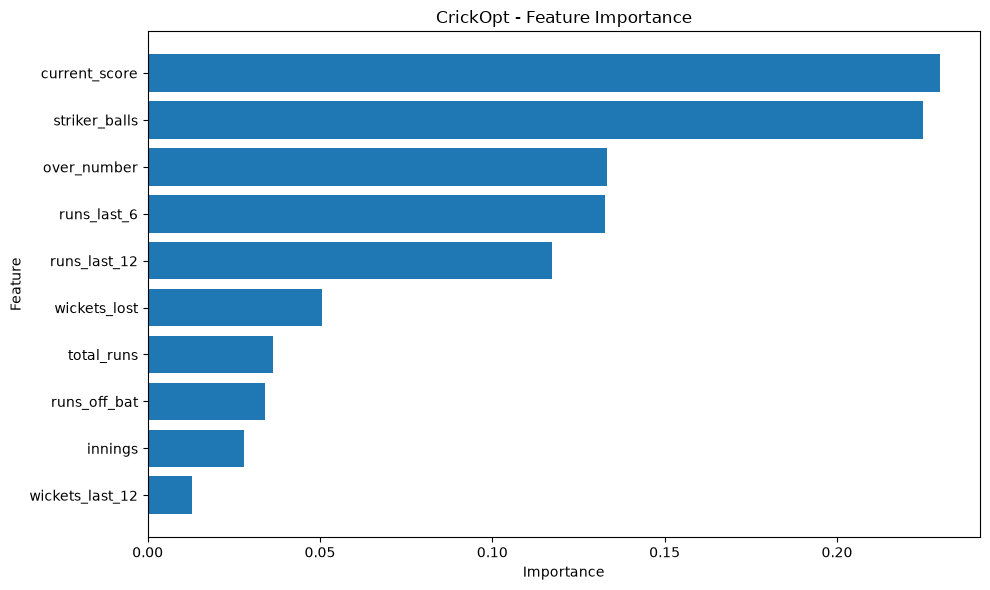

In [22]:
# STEP 19: Visualize feature importance

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("CrickOpt - Feature Importance")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [23]:
# STEP 20: CrickOpt prediction function

def predict_next_ball_runs(innings, over_number, current_score,
                           wickets_lost, runs_off_bat, total_runs,
                           runs_last_6, runs_last_12,
                           wickets_last_12, striker_balls):

    input_data = pd.DataFrame([{
        "innings": innings,
        "over_number": over_number,
        "current_score": current_score,
        "wickets_lost": wickets_lost,
        "runs_off_bat": runs_off_bat,
        "total_runs": total_runs,
        "runs_last_6": runs_last_6,
        "runs_last_12": runs_last_12,
        "wickets_last_12": wickets_last_12,
        "striker_balls": striker_balls
    }])

    prediction = rf_improved.predict(input_data)[0]

    return prediction


print("CrickOpt prediction function created successfully! 🏏")

CrickOpt prediction function created successfully! 🏏


In [24]:
# STEP 21: Test CrickOpt on a real match situation

sample = crickopt_data.iloc[100]

prediction = predict_next_ball_runs(
    innings=sample["innings"],
    over_number=sample["over_number"],
    current_score=sample["current_score"],
    wickets_lost=sample["wickets_lost"],
    runs_off_bat=sample["runs_off_bat"],
    total_runs=sample["total_runs"],
    runs_last_6=sample["runs_last_6"],
    runs_last_12=sample["runs_last_12"],
    wickets_last_12=sample["wickets_last_12"],
    striker_balls=sample["striker_balls"]
)

print("CrickOpt Tactical Prediction")
print("=" * 40)
print("Match ID:", sample["match_id"])
print("Innings:", sample["innings"])
print("Over:", sample["over_number"])
print("Current Score:", sample["current_score"])
print("Wickets Lost:", sample["wickets_lost"])
print("Striker:", sample["striker"])
print("Bowler:", sample["bowler"])
print("Recent 6-ball Runs:", sample["runs_last_6"])
print("Recent 12-ball Runs:", sample["runs_last_12"])
print("Predicted Next-Ball Runs:", round(prediction, 3))
print("Actual Next-Ball Runs:", sample["next_ball_runs"])

CrickOpt Tactical Prediction
Match ID: 64814
Innings: 1
Over: 16
Current Score: 66
Wickets Lost: 1
Striker: MS Sinclair
Bowler: Z Khan
Recent 6-ball Runs: 7.0
Recent 12-ball Runs: 14.0
Predicted Next-Ball Runs: 0.21
Actual Next-Ball Runs: 0.0


In [25]:
# STEP 22: Create batter and bowler performance features

# Batter's historical average runs per ball
batter_stats = (
    crickopt_data
    .groupby("striker")
    .agg(
        batter_avg_runs=("runs_off_bat", "mean"),
        batter_total_runs=("runs_off_bat", "sum"),
        batter_balls=("runs_off_bat", "count")
    )
    .reset_index()
)

# Bowler's historical runs conceded per ball
bowler_stats = (
    crickopt_data
    .groupby("bowler")
    .agg(
        bowler_avg_runs=("total_runs", "mean"),
        bowler_total_runs=("total_runs", "sum"),
        bowler_balls=("total_runs", "count"),
        bowler_wickets=("wicket", "sum")
    )
    .reset_index()
)

# Bowler wicket rate
bowler_stats["bowler_wicket_rate"] = (
    bowler_stats["bowler_wickets"] /
    bowler_stats["bowler_balls"]
)

# Add batter statistics
crickopt_data = crickopt_data.merge(
    batter_stats,
    on="striker",
    how="left"
)

# Add bowler statistics
crickopt_data = crickopt_data.merge(
    bowler_stats,
    on="bowler",
    how="left"
)

print("Batter and bowler performance features added!")

display(
    crickopt_data[
        [
            "striker",
            "batter_avg_runs",
            "batter_total_runs",
            "bowler",
            "bowler_avg_runs",
            "bowler_wicket_rate"
        ]
    ].head(10)
)

Batter and bowler performance features added!


,striker,batter_avg_runs,batter_total_runs,bowler,bowler_avg_runs,bowler_wicket_rate
0,SP Fleming,0.701483,2129,J Srinath,0.651355,0.031802
1,NJ Astle,0.751325,1559,J Srinath,0.651355,0.031802
2,NJ Astle,0.751325,1559,J Srinath,0.651355,0.031802
3,NJ Astle,0.751325,1559,J Srinath,0.651355,0.031802
4,SP Fleming,0.701483,2129,J Srinath,0.651355,0.031802
5,SP Fleming,0.701483,2129,J Srinath,0.651355,0.031802
6,NJ Astle,0.751325,1559,Z Khan,0.839186,0.028826
7,NJ Astle,0.751325,1559,Z Khan,0.839186,0.028826
8,NJ Astle,0.751325,1559,Z Khan,0.839186,0.028826
9,NJ Astle,0.751325,1559,Z Khan,0.839186,0.028826


In [26]:
# STEP 23: Build player-aware model dataset

player_features = [
    "innings",
    "over_number",
    "current_score",
    "wickets_lost",
    "runs_last_6",
    "runs_last_12",
    "wickets_last_12",
    "striker_balls",
    "batter_avg_runs",
    "batter_total_runs",
    "bowler_avg_runs",
    "bowler_wicket_rate"
]

player_model_data = crickopt_data[
    player_features + ["next_ball_runs"]
].copy()

# Remove any remaining missing values
player_model_data = player_model_data.dropna()

print("Player-aware dataset shape:", player_model_data.shape)

print("\nFeatures used:")
for feature in player_features:
    print("-", feature)

display(player_model_data.head())

Player-aware dataset shape: (1671360, 13)

Features used:
- innings
- over_number
- current_score
- wickets_lost
- runs_last_6
- runs_last_12
- wickets_last_12
- striker_balls
- batter_avg_runs
- batter_total_runs
- bowler_avg_runs
- bowler_wicket_rate


,innings,over_number,current_score,wickets_lost,runs_last_6,runs_last_12,wickets_last_12,striker_balls,batter_avg_runs,batter_total_runs,bowler_avg_runs,bowler_wicket_rate,next_ball_runs
1,1,0,1,0,1.0,1.0,0.0,0,0.751325,1559,0.651355,0.031802,0.0
2,1,0,1,0,1.0,1.0,0.0,1,0.751325,1559,0.651355,0.031802,1.0
3,1,0,2,0,1.0,1.0,0.0,2,0.751325,1559,0.651355,0.031802,0.0
4,1,0,2,0,2.0,2.0,0.0,1,0.701483,2129,0.651355,0.031802,0.0
5,1,0,2,0,2.0,2.0,0.0,2,0.701483,2129,0.651355,0.031802,1.0


In [27]:
# STEP 24: Build and train memory-efficient player-aware model

import gc
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Recreate player model data
player_features = [
    "innings",
    "over_number",
    "current_score",
    "wickets_lost",
    "runs_last_6",
    "runs_last_12",
    "wickets_last_12",
    "striker_balls",
    "batter_avg_runs",
    "batter_total_runs",
    "bowler_avg_runs",
    "bowler_wicket_rate"
]

player_model_data = crickopt_data[
    player_features + ["next_ball_runs"]
].dropna().copy()

print("Player-aware dataset:", player_model_data.shape)

# Use 300,000 rows to control RAM usage
sample_size = min(300000, len(player_model_data))

player_sample = player_model_data.sample(
    n=sample_size,
    random_state=42
)

X_player = player_sample[player_features]
y_player = player_sample["next_ball_runs"]

X_train_player, X_test_player, y_train_player, y_test_player = train_test_split(
    X_player,
    y_player,
    test_size=0.20,
    random_state=42
)

# Memory-efficient Random Forest
rf_player = RandomForestRegressor(
    n_estimators=30,
    max_depth=12,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=2
)

rf_player.fit(X_train_player, y_train_player)

print("\nPlayer-aware Random Forest trained successfully! 🏏🤖")
print("Training samples:", len(X_train_player))
print("Testing samples:", len(X_test_player))

Player-aware dataset: (1671360, 13)

Player-aware Random Forest trained successfully! 🏏🤖
Training samples: 240000
Testing samples: 60000


In [28]:
# STEP 25: Evaluate the player-aware model

# Make predictions
player_pred = rf_player.predict(X_test_player)

# Calculate metrics
player_mae = mean_absolute_error(y_test_player, player_pred)
player_rmse = np.sqrt(mean_squared_error(y_test_player, player_pred))
player_r2 = r2_score(y_test_player, player_pred)

print("CrickOpt Player-Aware Model Performance")
print("=" * 50)
print(f"MAE  : {player_mae:.4f}")
print(f"RMSE : {player_rmse:.4f}")
print(f"R²   : {player_r2:.4f}")

CrickOpt Player-Aware Model Performance
MAE  : 0.8489
RMSE : 1.2228
R²   : 0.0319


In [29]:
# STEP 26: Save the trained CrickOpt model

import joblib
from pathlib import Path

model_path = Path("../models/crickopt_player_model.pkl")

joblib.dump(rf_player, model_path)

print("CrickOpt model saved successfully!")
print("Saved at:", model_path)

CrickOpt model saved successfully!
Saved at: ..\models\crickopt_player_model.pkl


In [30]:
# STEP 27: CrickOpt Tactical Decision Engine

def crickopt_decision(sample):
    
    # Current match situation
    base = {
        "innings": sample["innings"],
        "over_number": sample["over_number"],
        "current_score": sample["current_score"],
        "wickets_lost": sample["wickets_lost"],
        "runs_off_bat": sample["runs_off_bat"],
        "total_runs": sample["total_runs"],
        "runs_last_6": sample["runs_last_6"],
        "runs_last_12": sample["runs_last_12"],
        "wickets_last_12": sample["wickets_last_12"],
        "striker_balls": sample["striker_balls"],
        "batter_avg_runs": sample["batter_avg_runs"],
        "batter_total_runs": sample["batter_total_runs"],
        "bowler_avg_runs": sample["bowler_avg_runs"],
        "bowler_wicket_rate": sample["bowler_wicket_rate"]
    }

    # Base prediction
    input_data = pd.DataFrame([base])[player_features]
    predicted_runs = rf_player.predict(input_data)[0]

    # Tactical scoring
    options = {
        "Normal": predicted_runs,
        "Defensive": predicted_runs * 0.90,
        "Wicket-taking": predicted_runs * 1.10
    }

    # Lower expected runs = better from bowling perspective
    best_option = min(options, key=options.get)

    print("🏏 CRICKOPT TACTICAL DECISION")
    print("=" * 45)

    print(f"Current Score: {sample['current_score']}")
    print(f"Wickets Lost: {sample['wickets_lost']}")
    print(f"Over: {sample['over_number']}")
    print(f"Striker: {sample['striker']}")
    print(f"Bowler: {sample['bowler']}")

    print("\nPredicted Next-Ball Runs:", round(predicted_runs, 3))

    print("\nTactical Options:")
    for option, score in options.items():
        print(f"{option}: {score:.3f}")

    print("\nCrickOpt Suggested Strategy:", best_option)

    return options

In [31]:
# STEP 28: Data-driven bowler recommendation

# Select a real match situation
sample = crickopt_data.iloc[100]

match_id = sample["match_id"]
innings = sample["innings"]

# Bowlers who have bowled in this innings before the current ball
previous_balls = crickopt_data[
    (crickopt_data["match_id"] == match_id) &
    (crickopt_data["innings"] == innings) &
    (crickopt_data.index < sample.name)
]

candidate_bowlers = previous_balls["bowler"].dropna().unique().tolist()

# Need at least one candidate
if len(candidate_bowlers) == 0:
    print("No previous bowlers available for this situation.")
else:
    recommendations = []

    for bowler in candidate_bowlers:
        
        # Get this bowler's historical statistics
        bowler_info = crickopt_data[
            crickopt_data["bowler"] == bowler
        ].iloc[0]

        input_row = {
            "innings": sample["innings"],
            "over_number": sample["over_number"],
            "current_score": sample["current_score"],
            "wickets_lost": sample["wickets_lost"],
            "runs_last_6": sample["runs_last_6"],
            "runs_last_12": sample["runs_last_12"],
            "wickets_last_12": sample["wickets_last_12"],
            "striker_balls": sample["striker_balls"],
            "batter_avg_runs": sample["batter_avg_runs"],
            "batter_total_runs": sample["batter_total_runs"],
            "bowler_avg_runs": bowler_info["bowler_avg_runs"],
            "bowler_wicket_rate": bowler_info["bowler_wicket_rate"]
        }

        input_df = pd.DataFrame([input_row])[player_features]

        predicted_runs = rf_player.predict(input_df)[0]

        recommendations.append({
            "Bowler": bowler,
            "Predicted Next-Ball Runs": predicted_runs,
            "Historical Runs/Ball": bowler_info["bowler_avg_runs"],
            "Historical Wicket Rate": bowler_info["bowler_wicket_rate"]
        })

    recommendation_table = pd.DataFrame(recommendations)

    recommendation_table = recommendation_table.sort_values(
        "Predicted Next-Ball Runs"
    ).reset_index(drop=True)

    print("🏏 CRICKOPT BOWLER COMPARISON")
    print("=" * 55)
    print("Match ID:", match_id)
    print("Innings:", innings)
    print("Current Score:", sample["current_score"])
    print("Wickets Lost:", sample["wickets_lost"])
    print("Over:", sample["over_number"])
    print("Striker:", sample["striker"])

    print("\nCandidate bowlers:", len(recommendation_table))

    display(recommendation_table.round(4))

🏏 CRICKOPT BOWLER COMPARISON
Match ID: 64814
Innings: 1
Current Score: 66
Wickets Lost: 1
Over: 16
Striker: MS Sinclair

Candidate bowlers: 3


,Bowler,Predicted Next-Ball Runs,Historical Runs/Ball,Historical Wicket Rate
0,J Srinath,0.5891,0.6514,0.0318
1,Z Khan,0.6917,0.8392,0.0288
2,A Nehra,0.7659,0.8967,0.0287


In [32]:
# STEP 29: Train a wicket prediction model

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score

# Features for wicket prediction
wicket_features = player_features

X_wicket = player_model_data[wicket_features]
y_wicket = crickopt_data.loc[
    player_model_data.index, "next_ball_wicket"
]

# Use the same 300,000-row sample size
wicket_sample = crickopt_data.loc[
    player_sample.index
].copy()

X_wicket = wicket_sample[wicket_features]
y_wicket = wicket_sample["next_ball_wicket"]

# Train/test split
X_train_wkt, X_test_wkt, y_train_wkt, y_test_wkt = train_test_split(
    X_wicket,
    y_wicket,
    test_size=0.20,
    random_state=42,
    stratify=y_wicket
)

# Memory-efficient classifier
wicket_model = RandomForestClassifier(
    n_estimators=30,
    max_depth=12,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=2,
    class_weight="balanced"
)

wicket_model.fit(X_train_wkt, y_train_wkt)

# Predictions
wicket_pred = wicket_model.predict(X_test_wkt)
wicket_prob = wicket_model.predict_proba(X_test_wkt)[:, 1]

print("CrickOpt Wicket Prediction Model trained! 🏏🤖")
print("Training samples:", len(X_train_wkt))
print("Testing samples:", len(X_test_wkt))

print("\nWicket Model Performance")
print("=" * 45)
print("Accuracy :", round(accuracy_score(y_test_wkt, wicket_pred), 4))
print("Precision:", round(precision_score(y_test_wkt, wicket_pred, zero_division=0), 4))
print("Recall   :", round(recall_score(y_test_wkt, wicket_pred, zero_division=0), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test_wkt, wicket_prob), 4))

CrickOpt Wicket Prediction Model trained! 🏏🤖
Training samples: 240000
Testing samples: 60000

Wicket Model Performance
Accuracy : 0.8331
Precision: 0.0545
Recall   : 0.313
ROC-AUC  : 0.6134


In [33]:
# STEP 30: Save CrickOpt models

import joblib
from pathlib import Path

models_path = Path("../models")

joblib.dump(rf_player, models_path / "crickopt_runs_model.pkl")
joblib.dump(wicket_model, models_path / "crickopt_wicket_model.pkl")

print("CrickOpt models saved successfully! 🏏🤖")
print("Runs model  :", models_path / "crickopt_runs_model.pkl")
print("Wicket model:", models_path / "crickopt_wicket_model.pkl")

CrickOpt models saved successfully! 🏏🤖
Runs model  : ..\models\crickopt_runs_model.pkl
Wicket model: ..\models\crickopt_wicket_model.pkl


In [34]:
# STEP 31: CrickOpt Tactical Score

def calculate_tactical_score(predicted_runs, wicket_probability):
    """
    Lower expected runs is better.
    Higher wicket probability is better.

    Weighting:
    70% expected-runs component
    30% wicket-probability component
    """

    # Convert runs into a 0-1 scale.
    # 6 runs is used as a reference maximum for one ball.
    run_component = min(predicted_runs / 6, 1)

    # Higher wicket probability should reduce the tactical score
    wicket_component = 1 - wicket_probability

    tactical_score = (
        0.70 * run_component +
        0.30 * wicket_component
    )

    return tactical_score


print("CrickOpt Tactical Score function created! 🏏")

CrickOpt Tactical Score function created! 🏏


In [35]:
# STEP 32: CrickOpt Tactical Recommendation Engine

def crickopt_recommend_bowler(sample):
    
    match_id = sample["match_id"]
    innings = sample["innings"]

    # Bowlers who have already bowled in this innings
    previous_balls = crickopt_data[
        (crickopt_data["match_id"] == match_id) &
        (crickopt_data["innings"] == innings) &
        (crickopt_data.index < sample.name)
    ]

    candidate_bowlers = previous_balls["bowler"].dropna().unique()

    results = []

    for bowler in candidate_bowlers:

        # Historical statistics for this bowler
        bowler_rows = crickopt_data[
            crickopt_data["bowler"] == bowler
        ]

        if len(bowler_rows) == 0:
            continue

        bowler_info = bowler_rows.iloc[0]

        # Create input for the runs model
        input_row = pd.DataFrame([{
            "innings": sample["innings"],
            "over_number": sample["over_number"],
            "current_score": sample["current_score"],
            "wickets_lost": sample["wickets_lost"],
            "runs_last_6": sample["runs_last_6"],
            "runs_last_12": sample["runs_last_12"],
            "wickets_last_12": sample["wickets_last_12"],
            "striker_balls": sample["striker_balls"],
            "batter_avg_runs": sample["batter_avg_runs"],
            "batter_total_runs": sample["batter_total_runs"],
            "bowler_avg_runs": bowler_info["bowler_avg_runs"],
            "bowler_wicket_rate": bowler_info["bowler_wicket_rate"]
        }])

        # Predict runs
        predicted_runs = rf_player.predict(
            input_row[player_features]
        )[0]

        # Predict wicket probability
        predicted_wicket_probability = wicket_model.predict_proba(
            input_row[wicket_features]
        )[0, 1]

        # Calculate tactical score
        tactical_score = calculate_tactical_score(
            predicted_runs,
            predicted_wicket_probability
        )

        results.append({
            "Bowler": bowler,
            "Predicted Runs": predicted_runs,
            "Wicket Probability": predicted_wicket_probability,
            "Tactical Score": tactical_score
        })

    if not results:
        print("No suitable candidate bowlers found.")
        return None

    result_df = pd.DataFrame(results)

    # Lower tactical score = lower modeled cost
    result_df = result_df.sort_values(
        "Tactical Score"
    ).reset_index(drop=True)

    print("🏏 CRICKOPT TACTICAL RECOMMENDATION")
    print("=" * 55)
    print(f"Match ID: {match_id}")
    print(f"Innings: {innings}")
    print(f"Current Score: {sample['current_score']}")
    print(f"Wickets Lost: {sample['wickets_lost']}")
    print(f"Over: {sample['over_number']}")
    print(f"Striker: {sample['striker']}")

    print("\nCandidate Bowlers:", len(result_df))

    display(result_df.round(4))

    return result_df

In [36]:
# STEP 33: Generate a CrickOpt recommendation

sample = crickopt_data.iloc[100]

recommendation = crickopt_recommend_bowler(sample)

🏏 CRICKOPT TACTICAL RECOMMENDATION
Match ID: 64814
Innings: 1
Current Score: 66
Wickets Lost: 1
Over: 16
Striker: MS Sinclair

Candidate Bowlers: 3


,Bowler,Predicted Runs,Wicket Probability,Tactical Score
0,J Srinath,0.5891,0.4528,0.2329
1,Z Khan,0.6917,0.4435,0.2477
2,A Nehra,0.7659,0.4549,0.2529


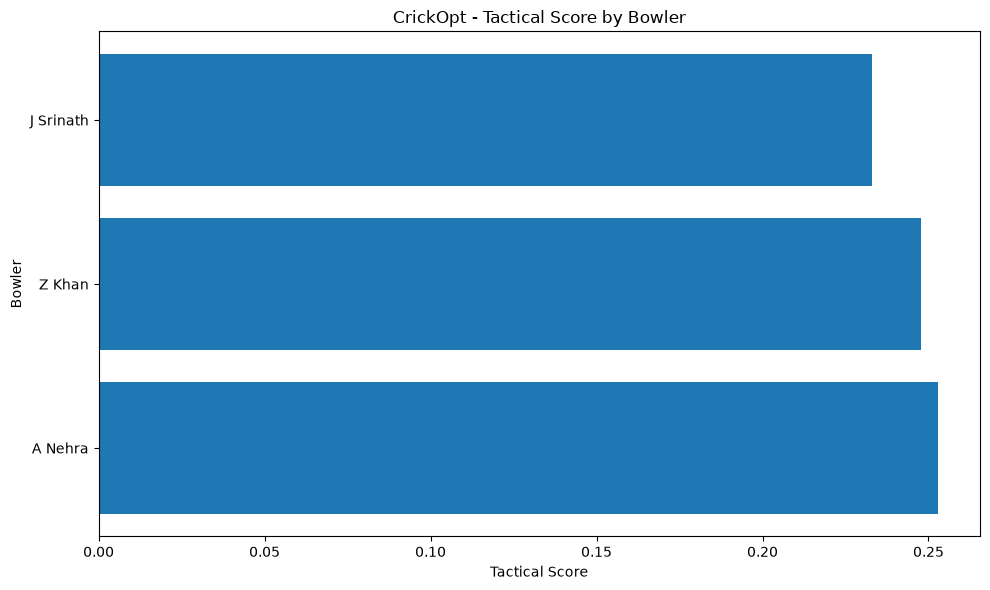

In [37]:
# STEP 34: Visualize CrickOpt tactical recommendations

import matplotlib.pyplot as plt

if recommendation is not None and len(recommendation) > 0:

    plot_data = recommendation.head(8).copy()

    plt.figure(figsize=(10, 6))

    plt.barh(
        plot_data["Bowler"],
        plot_data["Tactical Score"]
    )

    plt.xlabel("Tactical Score")
    plt.ylabel("Bowler")
    plt.title("CrickOpt - Tactical Score by Bowler")

    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

else:
    print("No recommendation data available.")

In [38]:
# STEP 35: Calculate match pressure

def calculate_pressure(row):
    
    score = row["current_score"]
    wickets = row["wickets_lost"]
    over = row["over_number"]
    recent_runs = row["runs_last_12"]

    # High pressure:
    # many wickets lost OR poor recent scoring
    if wickets >= 6 or recent_runs <= 8:
        return "High"

    # Medium pressure
    elif wickets >= 3 or recent_runs <= 15:
        return "Medium"

    # Otherwise
    else:
        return "Low"


crickopt_data["pressure_level"] = crickopt_data.apply(
    calculate_pressure,
    axis=1
)

print("Pressure feature created successfully! 🏏")

print("\nPressure distribution:")
print(crickopt_data["pressure_level"].value_counts())

display(
    crickopt_data[
        [
            "current_score",
            "wickets_lost",
            "over_number",
            "runs_last_12",
            "pressure_level"
        ]
    ].head(10)
)

Pressure feature created successfully! 🏏

Pressure distribution:
pressure_level
High      916946
Medium    658891
Low       101826
Name: count, dtype: int64


,current_score,wickets_lost,over_number,runs_last_12,pressure_level
0,1,0,0,NaN,Low
1,1,0,0,1.0,High
2,1,0,0,1.0,High
3,2,0,0,1.0,High
4,2,0,0,2.0,High
5,2,0,0,2.0,High
6,3,0,1,2.0,High
7,3,0,1,3.0,High
8,3,0,1,3.0,High
9,3,0,1,3.0,High


In [39]:
# STEP 36: Real-time CrickOpt Match Situation

def crickopt_live_analysis(
    innings,
    over_number,
    current_score,
    wickets_lost,
    runs_last_6,
    runs_last_12,
    wickets_last_12,
    striker_balls,
    batter_avg_runs,
    batter_total_runs,
    bowler_avg_runs,
    bowler_wicket_rate
):
    
    # Prepare current match situation
    input_data = pd.DataFrame([{
        "innings": innings,
        "over_number": over_number,
        "current_score": current_score,
        "wickets_lost": wickets_lost,
        "runs_last_6": runs_last_6,
        "runs_last_12": runs_last_12,
        "wickets_last_12": wickets_last_12,
        "striker_balls": striker_balls,
        "batter_avg_runs": batter_avg_runs,
        "batter_total_runs": batter_total_runs,
        "bowler_avg_runs": bowler_avg_runs,
        "bowler_wicket_rate": bowler_wicket_rate
    }])

    # Predict next-ball runs
    predicted_runs = rf_player.predict(
        input_data[player_features]
    )[0]

    # Predict wicket probability
    wicket_probability = wicket_model.predict_proba(
        input_data[wicket_features]
    )[0, 1]

    # Tactical score
    tactical_score = calculate_tactical_score(
        predicted_runs,
        wicket_probability
    )

    # Pressure
    if wickets_lost >= 6 or runs_last_12 <= 8:
        pressure = "High"
    elif wickets_lost >= 3 or runs_last_12 <= 15:
        pressure = "Medium"
    else:
        pressure = "Low"

    print("🏏 CRICKOPT LIVE MATCH ANALYSIS")
    print("=" * 50)

    print(f"Score: {current_score}/{wickets_lost}")
    print(f"Over: {over_number}")
    print(f"Pressure Level: {pressure}")

    print("\nPredicted Next-Ball Runs:",
          round(predicted_runs, 3))

    print("Predicted Wicket Probability:",
          round(wicket_probability, 3))

    print("Tactical Score:",
          round(tactical_score, 3))

    return {
        "predicted_runs": predicted_runs,
        "wicket_probability": wicket_probability,
        "tactical_score": tactical_score,
        "pressure": pressure
    }


print("CrickOpt live analysis system created! 🏏🤖")

CrickOpt live analysis system created! 🏏🤖


In [40]:
# STEP 37: Test CrickOpt with a live match situation

live_result = crickopt_live_analysis(
    innings=2,
    over_number=27,
    current_score=145,
    wickets_lost=3,
    runs_last_6=4,
    runs_last_12=11,
    wickets_last_12=0,
    striker_balls=32,
    batter_avg_runs=0.95,
    batter_total_runs=850,
    bowler_avg_runs=0.75,
    bowler_wicket_rate=0.025
)

🏏 CRICKOPT LIVE MATCH ANALYSIS
Score: 145/3
Over: 27
Pressure Level: Medium

Predicted Next-Ball Runs: 0.84
Predicted Wicket Probability: 0.497
Tactical Score: 0.249


In [41]:
# STEP 38: Batter-Bowler Matchup Statistics

matchup_stats = (
    crickopt_data
    .groupby(["striker", "bowler"])
    .agg(
        matchup_balls=("total_runs", "count"),
        matchup_runs=("total_runs", "sum"),
        matchup_wickets=("wicket", "sum")
    )
    .reset_index()
)

# Runs conceded per ball in the matchup
matchup_stats["matchup_runs_per_ball"] = (
    matchup_stats["matchup_runs"] /
    matchup_stats["matchup_balls"]
)

# Wicket rate in the matchup
matchup_stats["matchup_wicket_rate"] = (
    matchup_stats["matchup_wickets"] /
    matchup_stats["matchup_balls"]
)

print("Batter-Bowler matchup statistics created!")

print("\nNumber of unique batter-bowler matchups:",
      len(matchup_stats))

display(matchup_stats.head(10))

Batter-Bowler matchup statistics created!

Number of unique batter-bowler matchups: 97187


,striker,bowler,matchup_balls,matchup_runs,matchup_wickets,matchup_runs_per_ball,matchup_wicket_rate
0,A Aitken-Drummond,ASS Fletcher,2,3,0,1.500000,0.000000
1,A Aitken-Drummond,CA Henry,14,13,0,0.928571,0.000000
2,A Aitken-Drummond,CS Fraser,2,0,0,0.000000,0.000000
3,A Aitken-Drummond,Diana Baig,2,2,0,1.000000,0.000000
4,A Aitken-Drummond,GP Tom,14,4,1,0.285714,0.071429
5,A Aitken-Drummond,HJ Thomas,2,1,0,0.500000,0.000000
6,A Aitken-Drummond,HK Matthews,2,4,1,2.000000,0.500000
7,A Aitken-Drummond,HWA Landheer,13,15,1,1.153846,0.076923
8,A Aitken-Drummond,IJR Zwilling,8,4,0,0.500000,0.000000
9,A Aitken-Drummond,Marufa Akter,3,1,1,0.333333,0.333333


In [42]:
# STEP 39: Matchup-aware CrickOpt recommendation

def matchup_aware_recommendation(sample):

    match_id = sample["match_id"]
    innings = sample["innings"]
    striker = sample["striker"]

    # Bowlers already used in this innings
    previous_balls = crickopt_data[
        (crickopt_data["match_id"] == match_id) &
        (crickopt_data["innings"] == innings) &
        (crickopt_data.index < sample.name)
    ]

    candidate_bowlers = previous_balls["bowler"].dropna().unique()

    results = []

    for bowler in candidate_bowlers:

        # Historical bowler information
        bowler_rows = crickopt_data[
            crickopt_data["bowler"] == bowler
        ]

        if len(bowler_rows) == 0:
            continue

        bowler_info = bowler_rows.iloc[0]

        # Batter-bowler matchup
        matchup = matchup_stats[
            (matchup_stats["striker"] == striker) &
            (matchup_stats["bowler"] == bowler)
        ]

        # Default values if no previous matchup exists
        if len(matchup) > 0:
            matchup_info = matchup.iloc[0]

            matchup_runs_rate = matchup_info["matchup_runs_per_ball"]
            matchup_wicket_rate = matchup_info["matchup_wicket_rate"]
            matchup_balls = matchup_info["matchup_balls"]

        else:
            matchup_runs_rate = bowler_info["bowler_avg_runs"]
            matchup_wicket_rate = bowler_info["bowler_wicket_rate"]
            matchup_balls = 0

        # Model input
        input_row = pd.DataFrame([{
            "innings": sample["innings"],
            "over_number": sample["over_number"],
            "current_score": sample["current_score"],
            "wickets_lost": sample["wickets_lost"],
            "runs_last_6": sample["runs_last_6"],
            "runs_last_12": sample["runs_last_12"],
            "wickets_last_12": sample["wickets_last_12"],
            "striker_balls": sample["striker_balls"],
            "batter_avg_runs": sample["batter_avg_runs"],
            "batter_total_runs": sample["batter_total_runs"],
            "bowler_avg_runs": bowler_info["bowler_avg_runs"],
            "bowler_wicket_rate": bowler_info["bowler_wicket_rate"]
        }])

        # ML predictions
        predicted_runs = rf_player.predict(
            input_row[player_features]
        )[0]

        predicted_wicket_probability = wicket_model.predict_proba(
            input_row[wicket_features]
        )[0, 1]

        # Combine model + matchup information
        adjusted_runs = (
            0.70 * predicted_runs +
            0.30 * matchup_runs_rate
        )

        adjusted_wicket_probability = (
            0.70 * predicted_wicket_probability +
            0.30 * matchup_wicket_rate
        )

        tactical_score = calculate_tactical_score(
            adjusted_runs,
            adjusted_wicket_probability
        )

        results.append({
            "Bowler": bowler,
            "Predicted Runs": predicted_runs,
            "Matchup Runs/Ball": matchup_runs_rate,
            "Predicted Wicket Probability": predicted_wicket_probability,
            "Matchup Wicket Rate": matchup_wicket_rate,
            "Matchup Balls": matchup_balls,
            "Tactical Score": tactical_score
        })

    if not results:
        print("No candidate bowlers found.")
        return None

    result_df = pd.DataFrame(results)

    result_df = result_df.sort_values(
        "Tactical Score"
    ).reset_index(drop=True)

    print("🏏 CRICKOPT MATCHUP-AWARE RECOMMENDATION")
    print("=" * 60)
    print("Striker:", striker)
    print("Current Score:", sample["current_score"])
    print("Wickets Lost:", sample["wickets_lost"])
    print("Over:", sample["over_number"])

    display(result_df.round(4))

    return result_df


print("Matchup-aware recommendation engine created! 🏏🤖")

Matchup-aware recommendation engine created! 🏏🤖


In [43]:
# STEP 40: Test the matchup-aware recommendation

sample = crickopt_data.iloc[100]

matchup_recommendation = matchup_aware_recommendation(sample)

🏏 CRICKOPT MATCHUP-AWARE RECOMMENDATION
Striker: MS Sinclair
Current Score: 66
Wickets Lost: 1
Over: 16


,Bowler,Predicted Runs,Matchup Runs/Ball,Predicted Wicket Probability,Matchup Wicket Rate,Matchup Balls,Tactical Score
0,J Srinath,0.5891,0.5192,0.4528,0.0192,52,0.2695
1,Z Khan,0.6917,0.4643,0.4435,0.0357,28,0.2764
2,A Nehra,0.7659,0.6667,0.4549,0.0000,45,0.2903


In [44]:
# STEP 41: Create past-only player statistics

# Make sure balls are in chronological order
crickopt_data = crickopt_data.sort_values(
    ["match_id", "innings", "actual_delivery"]
).reset_index(drop=True)

# Past batter statistics
crickopt_data["batter_past_runs"] = (
    crickopt_data
    .groupby("striker")["runs_off_bat"]
    .cumsum()
    - crickopt_data["runs_off_bat"]
)

crickopt_data["batter_past_balls"] = (
    crickopt_data
    .groupby("striker")
    .cumcount()
)

crickopt_data["batter_past_avg"] = (
    crickopt_data["batter_past_runs"] /
    crickopt_data["batter_past_balls"].replace(0, np.nan)
)

# Past bowler statistics
crickopt_data["bowler_past_runs"] = (
    crickopt_data
    .groupby("bowler")["total_runs"]
    .cumsum()
    - crickopt_data["total_runs"]
)

crickopt_data["bowler_past_balls"] = (
    crickopt_data
    .groupby("bowler")
    .cumcount()
)

crickopt_data["bowler_past_wickets"] = (
    crickopt_data
    .groupby("bowler")["wicket"]
    .cumsum()
    - crickopt_data["wicket"]
)

crickopt_data["bowler_past_runs_per_ball"] = (
    crickopt_data["bowler_past_runs"] /
    crickopt_data["bowler_past_balls"].replace(0, np.nan)
)

crickopt_data["bowler_past_wicket_rate"] = (
    crickopt_data["bowler_past_wickets"] /
    crickopt_data["bowler_past_balls"].replace(0, np.nan)
)

print("Past-only player statistics created!")

display(
    crickopt_data[
        [
            "striker",
            "batter_past_runs",
            "batter_past_balls",
            "batter_past_avg",
            "bowler",
            "bowler_past_runs",
            "bowler_past_balls",
            "bowler_past_wickets",
            "bowler_past_runs_per_ball",
            "bowler_past_wicket_rate"
        ]
    ].head(10)
)

Past-only player statistics created!


,striker,batter_past_runs,batter_past_balls,batter_past_avg,bowler,bowler_past_runs,bowler_past_balls,bowler_past_wickets,bowler_past_runs_per_ball,bowler_past_wicket_rate
0,SP Fleming,0,0,NaN,J Srinath,0,0,0,NaN,NaN
1,NJ Astle,0,0,NaN,J Srinath,1,1,0,1.000000,0.0
2,NJ Astle,0,1,0.000000,J Srinath,1,2,0,0.500000,0.0
3,NJ Astle,0,2,0.000000,J Srinath,1,3,0,0.333333,0.0
4,SP Fleming,0,1,0.000000,J Srinath,2,4,0,0.500000,0.0
5,SP Fleming,0,2,0.000000,J Srinath,2,5,0,0.400000,0.0
6,NJ Astle,1,3,0.333333,Z Khan,0,0,0,NaN,NaN
7,NJ Astle,1,4,0.250000,Z Khan,1,1,0,1.000000,0.0
8,NJ Astle,1,5,0.200000,Z Khan,1,2,0,0.500000,0.0
9,NJ Astle,1,6,0.166667,Z Khan,1,3,0,0.333333,0.0


In [45]:
# STEP 42: Create past-only batter-bowler matchup features

# Cumulative matchup statistics BEFORE the current ball
matchup_group = crickopt_data.groupby(
    ["striker", "bowler"]
)

crickopt_data["matchup_past_runs"] = (
    matchup_group["total_runs"].cumsum()
    - crickopt_data["total_runs"]
)

crickopt_data["matchup_past_balls"] = (
    matchup_group.cumcount()
)

crickopt_data["matchup_past_wickets"] = (
    matchup_group["wicket"].cumsum()
    - crickopt_data["wicket"]
)

# Avoid division by zero
balls = crickopt_data["matchup_past_balls"].replace(0, np.nan)

crickopt_data["matchup_past_runs_per_ball"] = (
    crickopt_data["matchup_past_runs"] / balls
)

crickopt_data["matchup_past_wicket_rate"] = (
    crickopt_data["matchup_past_wickets"] / balls
)

print("Past-only batter-bowler matchup features created!")

display(
    crickopt_data[
        [
            "striker",
            "bowler",
            "matchup_past_runs",
            "matchup_past_balls",
            "matchup_past_wickets",
            "matchup_past_runs_per_ball",
            "matchup_past_wicket_rate"
        ]
    ].head(15)
)

Past-only batter-bowler matchup features created!


,striker,bowler,matchup_past_runs,matchup_past_balls,matchup_past_wickets,matchup_past_runs_per_ball,matchup_past_wicket_rate
0,SP Fleming,J Srinath,0,0,0,NaN,NaN
1,NJ Astle,J Srinath,0,0,0,NaN,NaN
2,NJ Astle,J Srinath,0,1,0,0.000000,0.0
3,NJ Astle,J Srinath,0,2,0,0.000000,0.0
4,SP Fleming,J Srinath,1,1,0,1.000000,0.0
5,SP Fleming,J Srinath,1,2,0,0.500000,0.0
6,NJ Astle,Z Khan,0,0,0,NaN,NaN
7,NJ Astle,Z Khan,1,1,0,1.000000,0.0
8,NJ Astle,Z Khan,1,2,0,0.500000,0.0
9,NJ Astle,Z Khan,1,3,0,0.333333,0.0


In [46]:
# STEP 43: Build the leakage-safe CrickOpt dataset

final_features = [
    "innings",
    "over_number",
    "current_score",
    "wickets_lost",
    "runs_last_6",
    "runs_last_12",
    "wickets_last_12",
    "striker_balls",
    "batter_past_avg",
    "bowler_past_runs_per_ball",
    "bowler_past_wicket_rate",
    "matchup_past_runs_per_ball",
    "matchup_past_wicket_rate"
]

final_data = crickopt_data[
    final_features + ["next_ball_runs", "next_ball_wicket"]
].copy()

# Replace unavailable historical statistics with 0
# (this mainly affects a player's/matchup's first appearance)
final_data[final_features] = final_data[final_features].fillna(0)

print("Final leakage-safe dataset created!")
print("Shape:", final_data.shape)

print("\nFeatures:")
for feature in final_features:
    print("-", feature)

display(final_data.head(10))

Final leakage-safe dataset created!
Shape: (1677663, 15)

Features:
- innings
- over_number
- current_score
- wickets_lost
- runs_last_6
- runs_last_12
- wickets_last_12
- striker_balls
- batter_past_avg
- bowler_past_runs_per_ball
- bowler_past_wicket_rate
- matchup_past_runs_per_ball
- matchup_past_wicket_rate


,innings,over_number,current_score,wickets_lost,runs_last_6,runs_last_12,wickets_last_12,striker_balls,batter_past_avg,bowler_past_runs_per_ball,bowler_past_wicket_rate,matchup_past_runs_per_ball,matchup_past_wicket_rate,next_ball_runs,next_ball_wicket
0,1,0,1,0,0.0,0.0,0.0,0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0
1,1,0,1,0,1.0,1.0,0.0,0,0.000000,1.000000,0.0,0.000000,0.0,0.0,0.0
2,1,0,1,0,1.0,1.0,0.0,1,0.000000,0.500000,0.0,0.000000,0.0,1.0,0.0
3,1,0,2,0,1.0,1.0,0.0,2,0.000000,0.333333,0.0,0.000000,0.0,0.0,0.0
4,1,0,2,0,2.0,2.0,0.0,1,0.000000,0.500000,0.0,1.000000,0.0,0.0,0.0
5,1,0,2,0,2.0,2.0,0.0,2,0.000000,0.400000,0.0,0.500000,0.0,1.0,0.0
6,1,1,3,0,2.0,2.0,0.0,3,0.333333,0.000000,0.0,0.000000,0.0,0.0,0.0
7,1,1,3,0,2.0,3.0,0.0,4,0.250000,1.000000,0.0,1.000000,0.0,0.0,0.0
8,1,1,3,0,2.0,3.0,0.0,5,0.200000,0.500000,0.0,0.500000,0.0,0.0,0.0
9,1,1,3,0,2.0,3.0,0.0,6,0.166667,0.333333,0.0,0.333333,0.0,0.0,0.0


In [47]:
# STEP 44: Chronological train/test split

# Keep the original chronological order
split_index = int(len(final_data) * 0.80)

train_data = final_data.iloc[:split_index].copy()
test_data = final_data.iloc[split_index:].copy()

X_train_final = train_data[final_features]
y_train_final = train_data["next_ball_runs"]

X_test_final = test_data[final_features]
y_test_final = test_data["next_ball_runs"]

print("Chronological split completed!")
print("=" * 50)

print("Training rows:", len(train_data))
print("Testing rows :", len(test_data))

print("\nTraining percentage: 80%")
print("Testing percentage : 20%")

Chronological split completed!
Training rows: 1342130
Testing rows : 335533

Training percentage: 80%
Testing percentage : 20%


In [48]:
# STEP 45: Train the final leakage-safe CrickOpt model

from sklearn.ensemble import RandomForestRegressor

final_model = RandomForestRegressor(
    n_estimators=30,
    max_depth=12,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=2
)

final_model.fit(
    X_train_final,
    y_train_final
)

print("Final CrickOpt model trained successfully! 🏏🤖")
print("Training rows:", len(X_train_final))
print("Testing rows:", len(X_test_final))

Final CrickOpt model trained successfully! 🏏🤖
Training rows: 1342130
Testing rows: 335533


In [49]:
# STEP 46: Evaluate the final CrickOpt model

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predict on unseen test data
final_pred = final_model.predict(X_test_final)

# Calculate evaluation metrics
final_mae = mean_absolute_error(y_test_final, final_pred)
final_rmse = np.sqrt(mean_squared_error(y_test_final, final_pred))
final_r2 = r2_score(y_test_final, final_pred)

print("🏏 FINAL CRICKOPT MODEL PERFORMANCE")
print("=" * 50)
print(f"MAE  : {final_mae:.4f}")
print(f"RMSE : {final_rmse:.4f}")
print(f"R²   : {final_r2:.4f}")

🏏 FINAL CRICKOPT MODEL PERFORMANCE
MAE  : 0.8747
RMSE : 1.2676
R²   : 0.0292


In [50]:
print("🏏 CRICKOPT MODEL COMPARISON")
print("=" * 60)

print(f"Baseline Model      → MAE: {0.9252:.4f} | RMSE: {1.3161:.4f} | R²: {-0.1076:.4f}")
print(f"Momentum Model      → MAE: {0.9188:.4f} | RMSE: {1.2846:.4f} | R²: {-0.0553:.4f}")
print(f"Player-Aware Model  → MAE: {0.8489:.4f} | RMSE: {1.2228:.4f} | R²: {0.0319:.4f}")

print("\nFinal leakage-safe model:")
print(f"Final Model         → MAE: {final_mae:.4f} | RMSE: {final_rmse:.4f} | R²: {final_r2:.4f}")

🏏 CRICKOPT MODEL COMPARISON
Baseline Model      → MAE: 0.9252 | RMSE: 1.3161 | R²: -0.1076
Momentum Model      → MAE: 0.9188 | RMSE: 1.2846 | R²: -0.0553
Player-Aware Model  → MAE: 0.8489 | RMSE: 1.2228 | R²: 0.0319

Final leakage-safe model:
Final Model         → MAE: 0.8747 | RMSE: 1.2676 | R²: 0.0292


In [51]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

X_train_wicket = train_data[final_features]
y_train_wicket = train_data["next_ball_wicket"].astype(int)

X_test_wicket = test_data[final_features]
y_test_wicket = test_data["next_ball_wicket"].astype(int)

wicket_model_final = RandomForestClassifier(
    n_estimators=30,
    max_depth=12,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=2,
    class_weight="balanced"
)

wicket_model_final.fit(X_train_wicket, y_train_wicket)

wicket_pred = wicket_model_final.predict(X_test_wicket)
wicket_prob = wicket_model_final.predict_proba(X_test_wicket)[:, 1]

print("🏏 FINAL WICKET MODEL PERFORMANCE")
print("=" * 50)
print(f"Accuracy  : {accuracy_score(y_test_wicket, wicket_pred):.4f}")
print(f"Precision : {precision_score(y_test_wicket, wicket_pred, zero_division=0):.4f}")
print(f"Recall    : {recall_score(y_test_wicket, wicket_pred, zero_division=0):.4f}")
print(f"F1 Score  : {f1_score(y_test_wicket, wicket_pred, zero_division=0):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test_wicket, wicket_prob):.4f}")

🏏 FINAL WICKET MODEL PERFORMANCE
Accuracy  : 0.7963
Precision : 0.0519
Recall    : 0.3499
F1 Score  : 0.0903
ROC-AUC   : 0.5997


In [52]:
import joblib
from pathlib import Path

models_path = Path("../models")
models_path.mkdir(exist_ok=True)

# Save final runs prediction model
joblib.dump(
    final_model,
    models_path / "crickopt_final_runs_model.pkl"
)

# Save final wicket prediction model
joblib.dump(
    wicket_model_final,
    models_path / "crickopt_final_wicket_model.pkl"
)

print("✅ FINAL MODELS SAVED")
print("=" * 50)
print("Runs model   :", models_path / "crickopt_final_runs_model.pkl")
print("Wicket model :", models_path / "crickopt_final_wicket_model.pkl")

✅ FINAL MODELS SAVED
Runs model   : ..\models\crickopt_final_runs_model.pkl
Wicket model : ..\models\crickopt_final_wicket_model.pkl


In [53]:
def calculate_crickopt_score(predicted_runs, wicket_probability):
    """
    Higher score = better tactical outcome for the batting side.
    Lower predicted runs and higher wicket probability are better
    for the bowling side.
    """

    run_component = 1 - min(predicted_runs / 6, 1)
    wicket_component = wicket_probability

    tactical_score = (
        0.70 * run_component +
        0.30 * wicket_component
    )

    return tactical_score


# Generate predictions on the test set
runs_prediction = final_model.predict(X_test_final)
wicket_probability = wicket_model_final.predict_proba(
    X_test_wicket
)[:, 1]

# Calculate tactical score
tactical_scores = [
    calculate_crickopt_score(r, w)
    for r, w in zip(runs_prediction, wicket_probability)
]

print("🏏 CRICKOPT TACTICAL ENGINE")
print("=" * 50)
print(f"Average predicted runs     : {runs_prediction.mean():.4f}")
print(f"Average wicket probability : {wicket_probability.mean():.4f}")
print(f"Average tactical score     : {np.mean(tactical_scores):.4f}")

print("\n✅ Tactical score generated successfully.")

🏏 CRICKOPT TACTICAL ENGINE
Average predicted runs     : 0.8277
Average wicket probability : 0.4624
Average tactical score     : 0.7422

✅ Tactical score generated successfully.


In [54]:
def crickopt_bowler_optimizer(
    sample_row,
    candidate_bowlers,
    batter_name
):
    """
    CrickOpt tactical bowler selection optimizer.
    """

    results = []

    for bowler in candidate_bowlers:

        # Create a copy of the current match situation
        row = sample_row.copy()

        # Update the batter and bowler
        row["striker"] = batter_name
        row["bowler"] = bowler

        # Prepare model input
        model_input = pd.DataFrame(
            [row[final_features]]
        ).fillna(0)

        # Predict next-ball runs
        predicted_runs = final_model.predict(
            model_input
        )[0]

        # Predict wicket probability
        predicted_wicket_probability = (
            wicket_model_final.predict_proba(
                model_input
            )[0][1]
        )

        # Calculate tactical score
        tactical_score = calculate_crickopt_score(
            predicted_runs,
            predicted_wicket_probability
        )

        results.append({
            "Bowler": bowler,
            "Predicted Runs": predicted_runs,
            "Wicket Probability": predicted_wicket_probability,
            "Tactical Score": tactical_score
        })

    results_df = pd.DataFrame(results)

    # Highest score = strongest bowling tactical option
    results_df = results_df.sort_values(
        "Tactical Score",
        ascending=False
    ).reset_index(drop=True)

    return results_df

In [55]:
def crickopt_bowler_optimizer(
    match_id,
    innings,
    ball_number,
    candidate_bowlers,
    batter_name
):
    """
    CrickOpt bowler selection optimizer using
    past-only bowler, batter and matchup statistics.
    """

    # Current situation
    current_rows = crickopt_data[
        (crickopt_data["match_id"] == match_id) &
        (crickopt_data["innings"] == innings) &
        (crickopt_data["actual_delivery"] == ball_number)
    ]

    if current_rows.empty:
        print("❌ Current ball not found.")
        return None

    current = current_rows.iloc[0]

    results = []

    # Data available BEFORE the current ball
    history = crickopt_data[
        (
            (crickopt_data["match_id"] != match_id) |
            (crickopt_data["actual_delivery"] < ball_number)
        )
    ].copy()

    # Batter history
    batter_history = history[
        history["striker"] == batter_name
    ]

    batter_past_runs = batter_history["runs_off_bat"].sum()
    batter_past_balls = len(batter_history)

    batter_past_avg = (
        batter_past_runs / batter_past_balls
        if batter_past_balls > 0 else 0
    )

    for bowler in candidate_bowlers:

        # Bowler history
        bowler_history = history[
            history["bowler"] == bowler
        ]

        bowler_balls = len(bowler_history)
        bowler_runs = bowler_history["total_runs"].sum()
        bowler_wickets = bowler_history["wicket"].sum()

        bowler_runs_per_ball = (
            bowler_runs / bowler_balls
            if bowler_balls > 0 else 0
        )

        bowler_wicket_rate = (
            bowler_wickets / bowler_balls
            if bowler_balls > 0 else 0
        )

        # Batter vs bowler matchup history
        matchup_history = history[
            (history["striker"] == batter_name) &
            (history["bowler"] == bowler)
        ]

        matchup_balls = len(matchup_history)
        matchup_runs = matchup_history["total_runs"].sum()
        matchup_wickets = matchup_history["wicket"].sum()

        matchup_runs_per_ball = (
            matchup_runs / matchup_balls
            if matchup_balls > 0 else 0
        )

        matchup_wicket_rate = (
            matchup_wickets / matchup_balls
            if matchup_balls > 0 else 0
        )

        # Create model input
        model_row = pd.DataFrame([{
            "innings": innings,
            "over_number": current["over_number"],
            "current_score": current["current_score"],
            "wickets_lost": current["wickets_lost"],
            "runs_last_6": current["runs_last_6"],
            "runs_last_12": current["runs_last_12"],
            "wickets_last_12": current["wickets_last_12"],
            "striker_balls": current["striker_balls"],
            "batter_past_avg": batter_past_avg,
            "bowler_past_runs_per_ball": bowler_runs_per_ball,
            "bowler_past_wicket_rate": bowler_wicket_rate,
            "matchup_past_runs_per_ball": matchup_runs_per_ball,
            "matchup_past_wicket_rate": matchup_wicket_rate
        }])

        # Predictions
        predicted_runs = final_model.predict(
            model_row[final_features]
        )[0]

        wicket_probability = (
            wicket_model_final
            .predict_proba(model_row[final_features])[0][1]
        )

        tactical_score = calculate_crickopt_score(
            predicted_runs,
            wicket_probability
        )

        results.append({
            "Bowler": bowler,
            "Predicted Runs": predicted_runs,
            "Wicket Probability": wicket_probability,
            "Tactical Score": tactical_score,
            "Past Matchup Balls": matchup_balls
        })

    results_df = pd.DataFrame(results)

    return results_df.sort_values(
        "Tactical Score",
        ascending=False
    ).reset_index(drop=True)

In [56]:
# Select a real situation from the test dataset
test_start = split_index

# Pick a point sufficiently into an innings
sample_index = test_start + 500

sample = crickopt_data.iloc[sample_index]

match_id = sample["match_id"]
innings = sample["innings"]
ball_number = sample["actual_delivery"]
batter_name = sample["striker"]

# Find bowlers who have already bowled in this innings
previous_balls = crickopt_data.iloc[:sample_index]

candidate_bowlers = previous_balls[
    (previous_balls["match_id"] == match_id) &
    (previous_balls["innings"] == innings)
]["bowler"].dropna().unique().tolist()

print("🏏 CRICKOPT LIVE TACTICAL SITUATION")
print("=" * 55)
print(f"Match ID       : {match_id}")
print(f"Innings        : {innings}")
print(f"Over           : {sample['over_number']}")
print(f"Current Score  : {sample['current_score']}")
print(f"Wickets Lost   : {sample['wickets_lost']}")
print(f"Striker        : {batter_name}")
print(f"Candidate Bowlers: {candidate_bowlers}")

# Generate recommendation
recommendation = crickopt_bowler_optimizer(
    match_id=match_id,
    innings=innings,
    ball_number=ball_number,
    candidate_bowlers=candidate_bowlers,
    batter_name=batter_name
)

recommendation

🏏 CRICKOPT LIVE TACTICAL SITUATION
Match ID       : 1358083
Innings        : 1
Over           : 41
Current Score  : 153
Wickets Lost   : 5
Striker        : Aryan Lakra
Candidate Bowlers: ['Karan KC', 'Sompal Kami', 'Aarif Sheikh', 'Gulsan Jha', 'S Lamichhane', 'Kushal Malla', 'DS Airee']


,Bowler,Predicted Runs,Wicket Probability,Tactical Score,Past Matchup Balls
0,Karan KC,0.770574,0.579357,0.783907,30
1,S Lamichhane,0.687457,0.545931,0.783576,15
2,DS Airee,0.724112,0.556709,0.782533,19
3,Kushal Malla,0.719118,0.554292,0.782390,0
4,Sompal Kami,0.748862,0.564257,0.781910,24
5,Aarif Sheikh,0.871372,0.576623,0.771327,15
6,Gulsan Jha,0.843092,0.534433,0.761969,0


In [57]:
best_bowler = recommendation.iloc[0]

print("🏏 CRICKOPT TACTICAL RECOMMENDATION")
print("=" * 55)

print(f"Current Batter      : {batter_name}")
print(f"Current Score       : {sample['current_score']}")
print(f"Wickets Lost        : {sample['wickets_lost']}")
print(f"Over                : {sample['over_number']}")

print("\nRecommended Bowler  :", best_bowler["Bowler"])
print(f"Predicted Runs      : {best_bowler['Predicted Runs']:.3f}")
print(f"Wicket Probability  : {best_bowler['Wicket Probability']:.3f}")
print(f"Tactical Score      : {best_bowler['Tactical Score']:.3f}")

print("\n📊 Candidate Comparison")
print(
    recommendation[
        [
            "Bowler",
            "Predicted Runs",
            "Wicket Probability",
            "Tactical Score"
        ]
    ].to_string(index=False)
)

🏏 CRICKOPT TACTICAL RECOMMENDATION
Current Batter      : Aryan Lakra
Current Score       : 153
Wickets Lost        : 5
Over                : 41

Recommended Bowler  : Karan KC
Predicted Runs      : 0.771
Wicket Probability  : 0.579
Tactical Score      : 0.784

📊 Candidate Comparison
      Bowler  Predicted Runs  Wicket Probability  Tactical Score
    Karan KC        0.770574            0.579357        0.783907
S Lamichhane        0.687457            0.545931        0.783576
    DS Airee        0.724112            0.556709        0.782533
Kushal Malla        0.719118            0.554292        0.782390
 Sompal Kami        0.748862            0.564257        0.781910
Aarif Sheikh        0.871372            0.576623        0.771327
  Gulsan Jha        0.843092            0.534433        0.761969


In [58]:
recommendation.to_csv(
    "../models/crickopt_tactical_recommendation.csv",
    index=False
)

print("✅ Tactical recommendation saved successfully!")
print("../models/crickopt_tactical_recommendation.csv")

✅ Tactical recommendation saved successfully!
../models/crickopt_tactical_recommendation.csv


In [59]:
from pathlib import Path

models_path = Path("../models")

print("🏏 CRICKOPT MODEL FILES")
print("=" * 50)

for file in models_path.glob("*"):
    print("✅", file.name)

🏏 CRICKOPT MODEL FILES
✅ crickopt_final_runs_model.pkl
✅ crickopt_final_wicket_model.pkl
✅ crickopt_player_model.pkl
✅ crickopt_runs_model.pkl
✅ crickopt_tactical_recommendation.csv
✅ crickopt_wicket_model.pkl


# 🏏 CrickOpt — AI-Based Cricket Tactical Decision Optimization

## Project Overview

CrickOpt is an AI-based cricket analytics and tactical decision optimization system
that uses ODI ball-by-ball data to analyze match situations and generate
data-driven tactical recommendations.

## Dataset

- Source: Cricsheet ODI ball-by-ball dataset
- Format: CSV
- Matches: 3,182 ODI matches
- Data: Ball-by-ball match information

## Key Features

- Current score
- Wickets lost
- Over number
- Match phase
- Recent scoring momentum
- Recent wicket information
- Batter historical performance
- Bowler historical performance
- Batter-bowler matchup statistics

## Machine Learning Models

### 1. Runs Prediction Model
Predicts runs expected from the next delivery.

### 2. Wicket Prediction Model
Estimates the probability of a wicket on the next delivery.

### 3. Tactical Decision Engine
Combines runs prediction and wicket probability into a tactical score.

### 4. Bowler Optimization Module
Compares available bowlers and generates a tactical recommendation
based on the predicted outcome.

## Data Leakage Prevention

Player, bowler and batter-bowler matchup statistics were constructed
using past information only for the prediction point.

A chronological train-test split was used for the final model evaluation.

## Technologies Used

- Python
- Pandas
- NumPy
- Scikit-learn
- Matplotlib
- Joblib
- Jupyter Notebook
- VS Code

## Project Pipeline

ODI Ball-by-Ball Data
        ↓
Data Cleaning
        ↓
Feature Engineering
        ↓
Past-Only Historical Statistics
        ↓
Runs Prediction
        ↓
Wicket Probability Prediction
        ↓
Tactical Score
        ↓
Bowler Optimization
        ↓
Tactical Recommendation

## Project Objective

The objective of CrickOpt is to move beyond simple cricket prediction
and develop a decision-support system capable of evaluating tactical
options in different match situations.